### Value Class
Stores value children(parent really) and the op with which the current number was made

In [106]:
import math
from random import random


# From a design point of view the design of this class is genius, something that I couldn't come up with now
class Value:

    def __init__(self,data,_children=(),_op='',label = ''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data,(self,other),'+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data,(self,other),'*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __rmul__(self,other):
        return self * other

    def __pow__(self, power):
        assert isinstance(power,(int,float))
        out = Value(self.data ** power,(self,),f"**{power}")

        def _backward():
            self.grad += power * (self.data ** (power - 1)) * out.grad
        out._backward = _backward
        return out

    def __truediv__(self, other):
        return self * (other ** -1)

    def __neg__(self):
        return  self * -1

    def __sub__(self, other):
        return self + (-other)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t,(self,),'tanh')

        def _backward():
            self.grad += (1-t**2) * out.grad

        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x),(self,),"exp")

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)

                topo.append(v)
        build_topo(self)

        self.grad = 1
        for node in reversed(topo):
            node._backward()

In [107]:
a = Value(2.0,label='a')
b = Value(-3.0,label='b')
c = Value(10,label='c')
e = a*b; e.label = 'e'
d = e+c;d.label = 'd'
f = Value(-2.0,label = 'f')
L = d*f;L.label = "L"
L

Value(data=-8.0)

In [108]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad %.4f}" % (n.label,n.data,n.grad),
            shape='record'
        )

        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)

            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

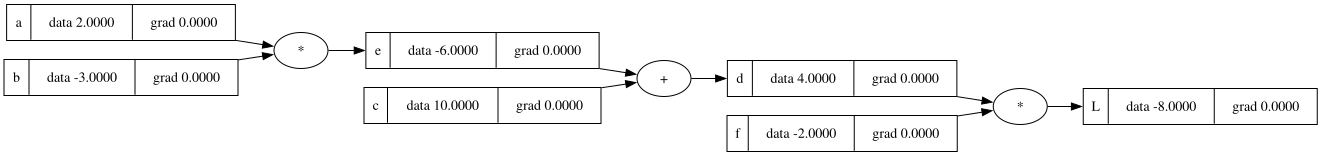

In [109]:
draw_dot(L)
# We want to find the derivative of L with respect to the variables it is made up of namely a,b,c,d,e,f

In [110]:
L.grad = 1
d.grad = f.data
f.grad = d.data

# Direct partial differentiation   L = d*f

 - We want dL/dc
 - we know c+e = d
 - Using chain rule dL/dc = dL/dd * dd/dc

- dd/dc = 1 and dd/de = 1 (kind of a local derivative)

In [111]:
c.grad = d.grad * 1
e.grad = d.grad * 1

In [112]:
b.grad = a.data * e.grad
a.grad = b.data * e.grad

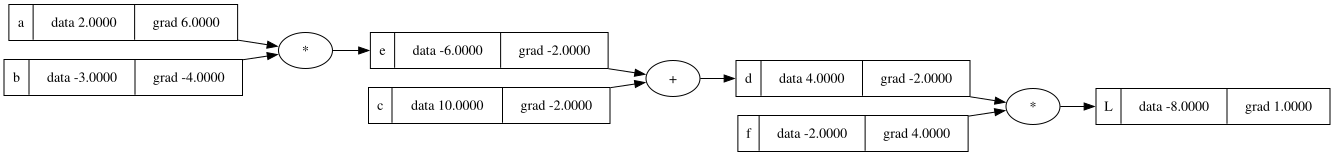

In [113]:
draw_dot(L)

### Mathematical model of a neuron
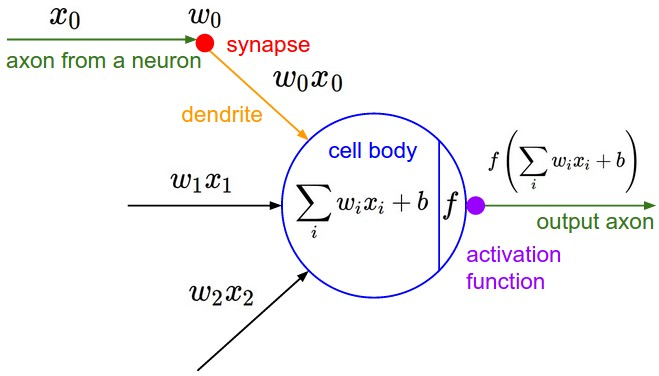

In [114]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1 * w1
x1w1.label = 'x1*w1'

x2w2 = x2 * w2
x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b
n.label = 'n'

o = n.tanh()
o.label = 'o'


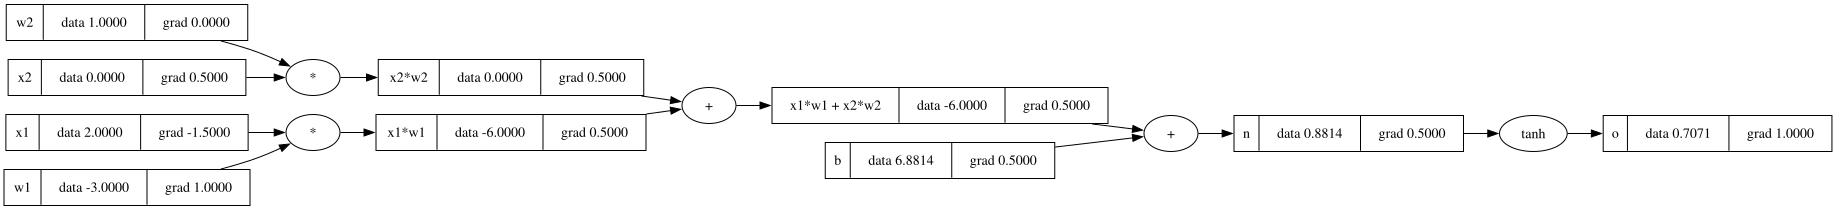

In [115]:
o.backward()
draw_dot(o)

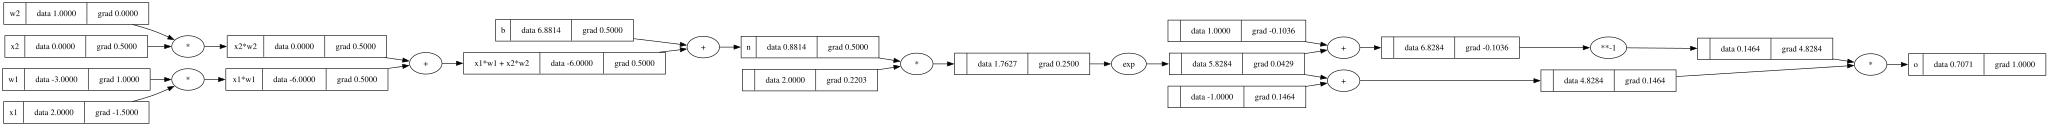

In [116]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1 * w1
x1w1.label = 'x1*w1'

x2w2 = x2 * w2
x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b
n.label = 'n'

e = (2*n).exp()
o = (e-1)/(e+1)
o.label = 'o'

o.backward()
draw_dot(o)

In [173]:
# neural network
import random
class Neuron:
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self,x):
        act = sum((wi * xi for wi,xi in zip(self.w,x)),self.b)
        out = act.tanh()

        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] + nouts

        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]



In [178]:
x = [2.0, 3.0, -1.0]

n = MLP(3, [4, 4, 1])

n(x)

Value(data=0.46269236993456003)

In [179]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0]  # desired targets

ypred = [n(x) for x in xs]
ypred

[Value(data=0.46269236993456003),
 Value(data=0.5693624036345085),
 Value(data=0.5395927063547414),
 Value(data=0.390278830802673)]

In [180]:
for k in range(30):
    ypred = [n(x) for x in xs]
    loss = sum(((yout-ygt)**2 for ygt,yout in zip(ys,ypred)),Value(0.0))

    for p in n.parameters():
        p.grad = 0.0

    loss.backward()

    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k,loss.data)



0 5.493703448896094
1 4.270280321679432
2 3.9499514525362023
3 3.811112041068635
4 3.6682687679932573
5 3.462868343335426
6 3.1401788932444457
7 2.6685314090998378
8 2.1023350599316295
9 1.5397782668707534
10 1.0839687713127661
11 0.770010837618
12 0.5697277641527262
13 0.440488984263794
14 0.35357713873920943
15 0.292403973770592
16 0.24758831345527166
17 0.21363213703490264
18 0.18717157986246133
19 0.1660625500081242
20 0.14888674888863926
21 0.13467473202442798
22 0.12274456633667821
23 0.11260435571135605
24 0.10389136472743098
25 0.09633284401888262
26 0.08972013421801182
27 0.08389112957553854
28 0.07871814212435344
29 0.07409933723525487


In [181]:
ypred

[Value(data=0.8692383097602578),
 Value(data=-0.8807020191704015),
 Value(data=-0.8520981160664254),
 Value(data=0.8554533220728309)]